## Download the Dataset

In [1]:
import kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Path to dataset files:", path)

100%|██████████| 429M/429M [00:03<00:00, 119MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


In [2]:
PATH = path

In [3]:
import os
for dirname, _, filenames in os.walk(PATH):
    for i , filename in enumerate(filenames):
        if (i == 10) : break
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-05-01-01-02-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-06-01-02-02-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-05-02-01-02-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-04-02-01-01-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-06-01-01-02-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-02-02-02-02-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-06-02-01-01-19.wav
/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-02-01-02-02-19.wav
/root/.cache/kagglehub/datasets/uwrfkagg

In [8]:

ravdess_path = PATH
crema_path = "/kaggle/input/cremad/AudioWAV/"
tess_path = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"
savee_path = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"

## Importing the Library

In [5]:
import pandas as pd
import numpy as np
import os
import sys
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from IPython.display import Audio

In [14]:
all_audio_path = []
for dirname, _, filenames in os.walk(ravdess_path):
    for filename in filenames:
        if filename.endswith('.wav'): # Ensure only WAV files are included
            all_audio_path.append(os.path.join(dirname, filename))

In [15]:
len(all_audio_path)

2880

In [16]:
all_audio_path[:5]

['/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-05-01-01-02-19.wav',
 '/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-06-01-02-02-19.wav',
 '/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-05-02-01-02-19.wav',
 '/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-04-02-01-01-19.wav',
 '/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-06-01-01-02-19.wav']

In [ ]:
import os

file_emotion, file_path = [], []
for audio in all_audio_path:
    basename = os.path.basename(audio)
    # get filename without extension
    filename_without_ext = os.path.splitext(basename)[0]
    part = filename_without_ext.split('-')
    # third part in each file represents the emotion associated to that file.
    file_emotion.append(int(part[2]))
    file_path.append(audio)
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

#creating the map for emotions 
Ravdess_df.Emotions.replace({1:'neutral',
                             2:'calm',
                             3:'happy',
                             4:'sad',
                             5:'angry',
                             6:'fear',
                             7:'disgust',
                             8:'surprise'
                             },
                             inplace=True)
Ravdess_df

/tmp/ipykernel_1100/2553445167.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Ravdess_df.Emotions.replace({1:'neutral',


,Emotions,Path
0,angry,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
1,fear,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2,angry,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
3,sad,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
4,fear,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
...,...,...
2875,disgust,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2876,calm,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2877,happy,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...
2878,happy,/root/.cache/kagglehub/datasets/uwrfkaggler/ra...


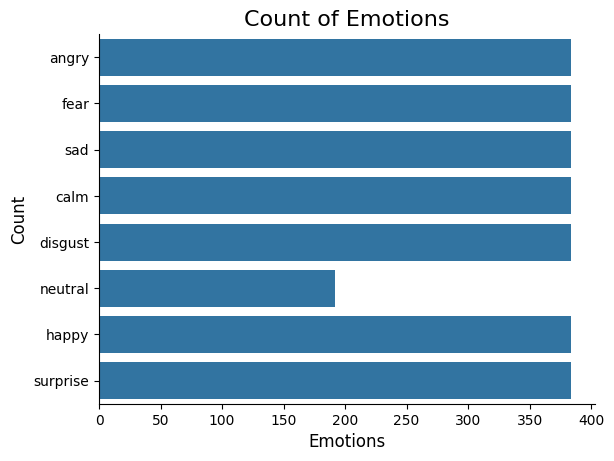

In [18]:

plt.title('Count of Emotions', size=16)
sns.countplot(Ravdess_df.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [19]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

In [ ]:
def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-06-01-01-02-19.wav


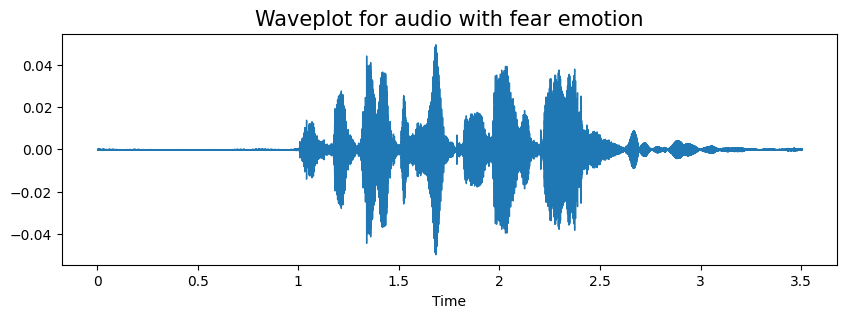

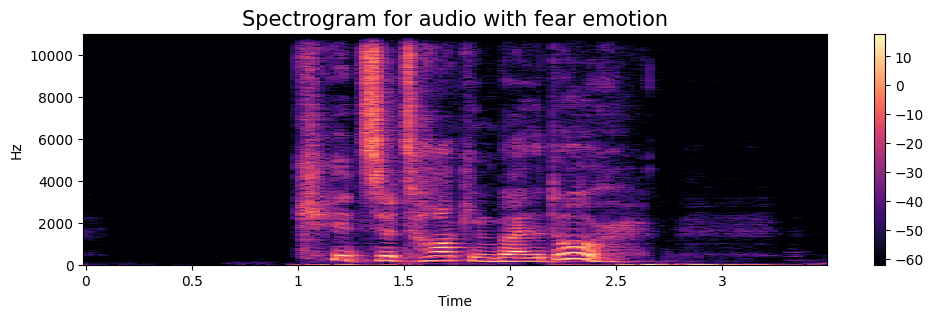

In [21]:
emotion='fear'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-05-02-01-02-19.wav


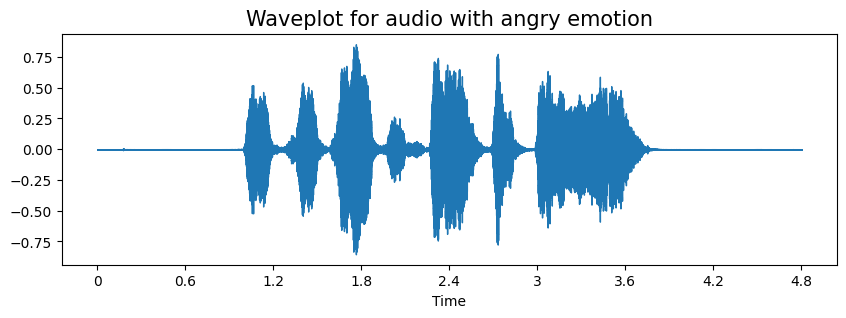

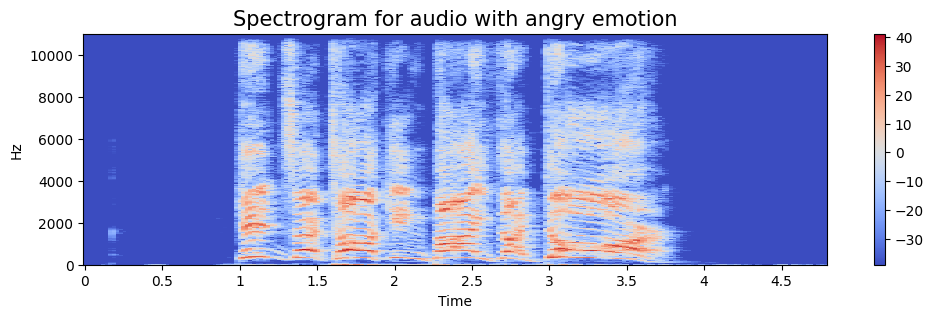

In [22]:

emotion='angry'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-04-01-01-01-19.wav


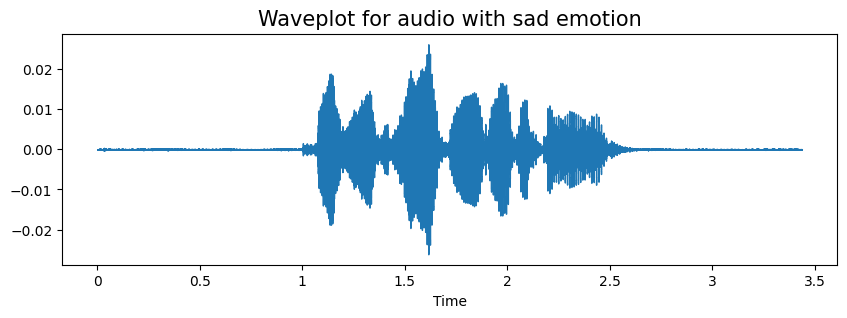

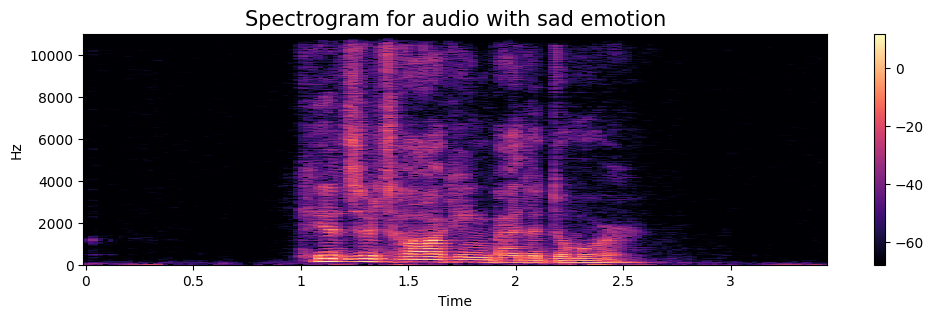

In [23]:

emotion='sad'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

/root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_19/03-01-03-01-01-01-19.wav


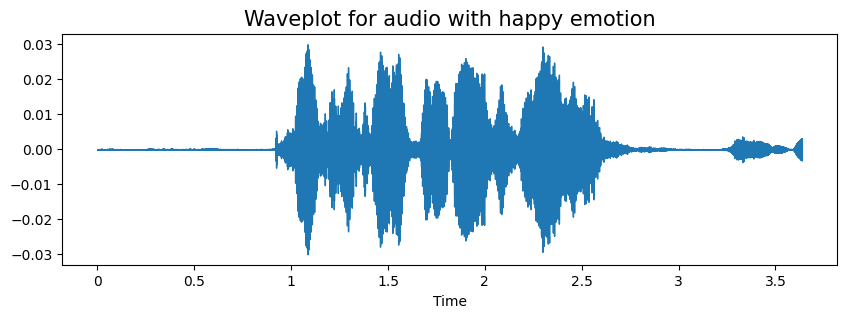

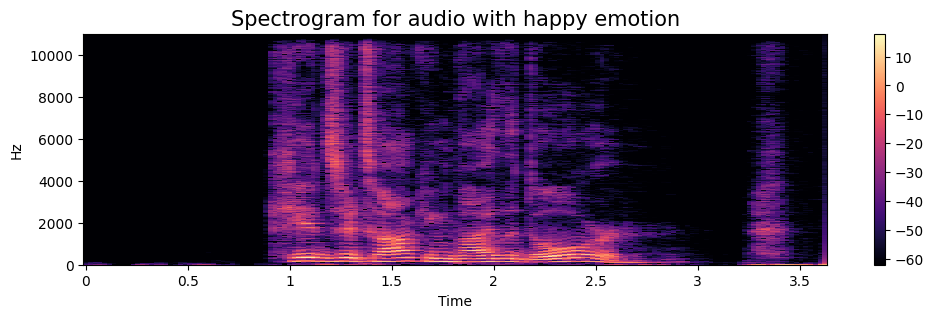

In [24]:

emotion='happy'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate=0.3, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# testing 
path = np.array(Ravdess_df.Path)[1]
data, sample_rate = librosa.load(path)

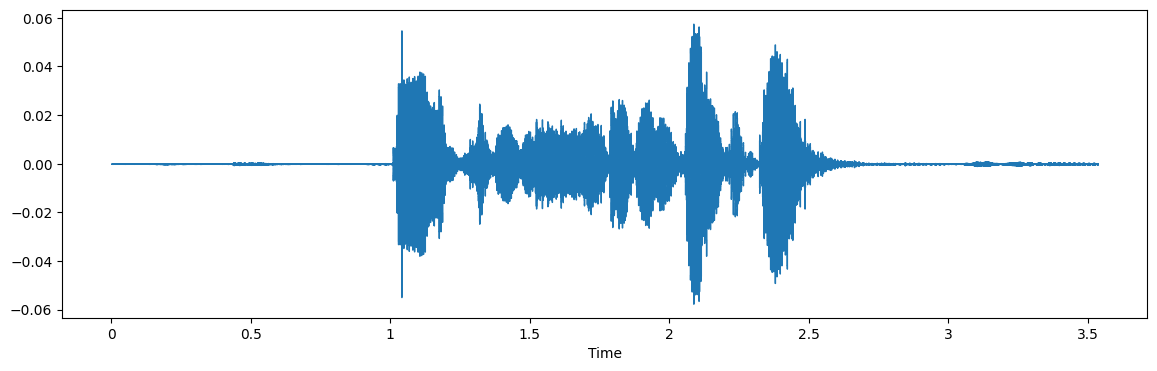

In [26]:

plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
Audio(path)

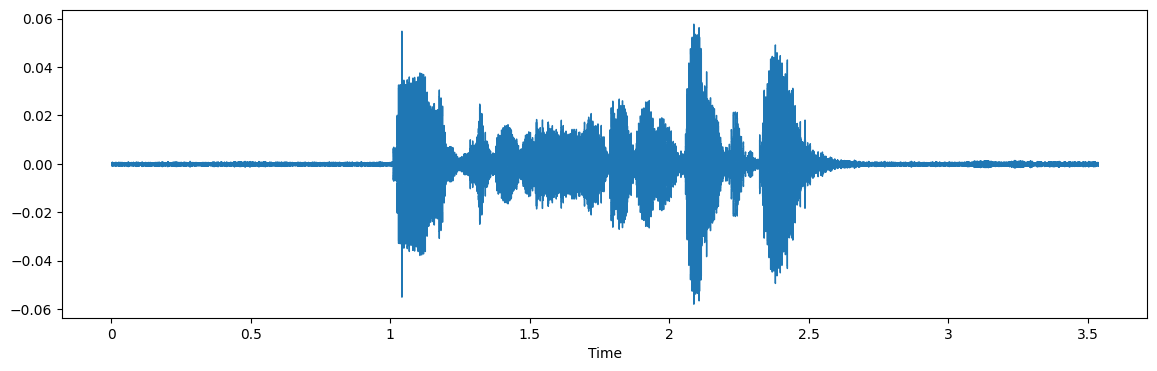

In [27]:
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

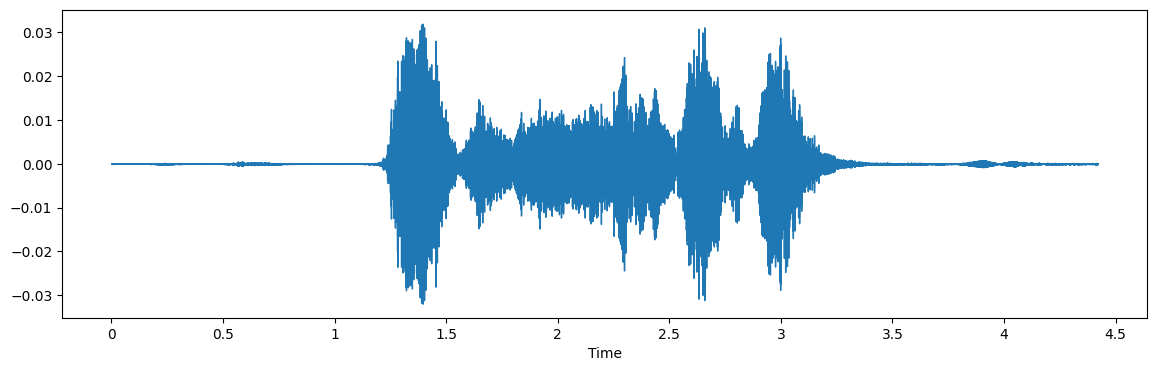

In [28]:
x = stretch(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

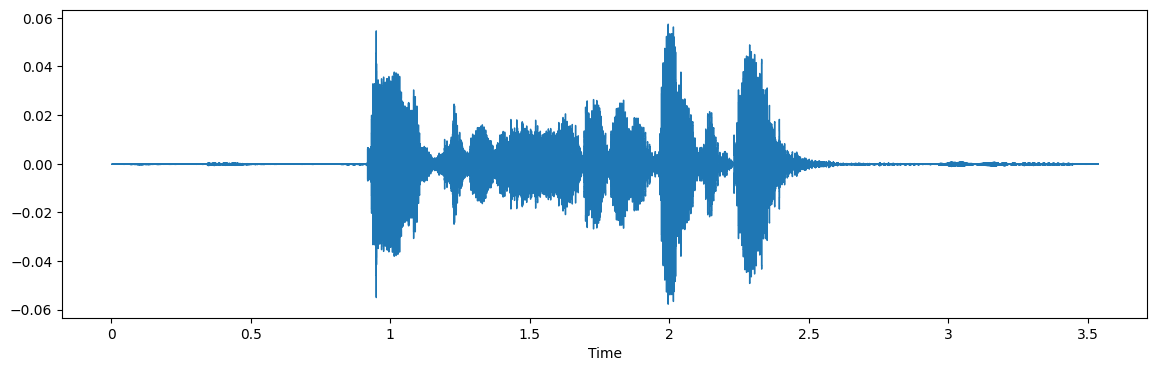

In [29]:

x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

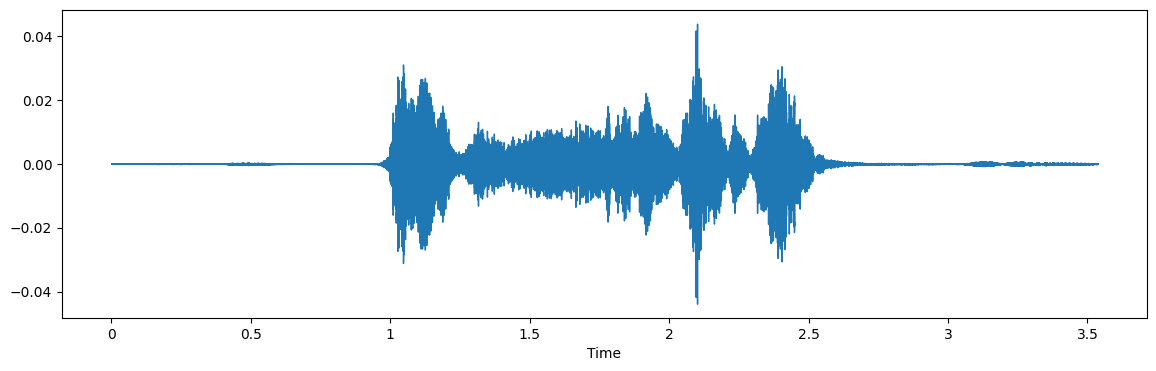

In [30]:

x = pitch(data, sample_rate)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

In [ ]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # mfcc
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # rms val
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # meospectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally

    return result

In [32]:

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)

    # without augmentation
    res1 = extract_features(data)
    result = np.array(res1)

    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically

    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically

    return result

In [33]:
X, Y = [], []
for path, emotion in zip(Ravdess_df.Path, Ravdess_df.Emotions):
    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)

In [34]:
len(X), len(Y), Ravdess_df.Path.shape

(8640, 8640, (2880,))

In [ ]:
import os

Features = pd.DataFrame(X)
Features['labels'] = Y

# start from thisdir
os.makedirs('/kaggle/working', exist_ok=True)

Features.to_csv('/kaggle/working/features.csv', index=False)
Features

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.139997,0.569794,0.578606,0.582895,0.579981,0.611889,0.676006,0.691394,0.722102,0.690109,...,0.000050,0.000087,0.000080,0.000084,0.000068,0.000060,0.000051,0.000032,2.778968e-06,angry
1,0.284252,0.717845,0.733807,0.714567,0.722277,0.740176,0.731475,0.694729,0.704979,0.688131,...,0.000429,0.000443,0.000433,0.000453,0.000469,0.000420,0.000394,0.000393,3.848644e-04,angry
2,0.141323,0.715714,0.615404,0.528066,0.535597,0.557037,0.543570,0.555981,0.555617,0.600018,...,0.000099,0.000055,0.000011,0.000010,0.000008,0.000006,0.000007,0.000005,5.069051e-07,angry
3,0.207578,0.689615,0.629829,0.620959,0.699310,0.691907,0.702438,0.625159,0.611265,0.644878,...,0.000078,0.000080,0.000066,0.000058,0.000065,0.000064,0.000055,0.000026,2.474816e-06,fear
4,0.316393,0.775832,0.757715,0.728587,0.790508,0.829797,0.780556,0.659573,0.640755,0.654734,...,0.000227,0.000222,0.000210,0.000202,0.000208,0.000200,0.000192,0.000158,1.478082e-04,fear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8635,0.308508,0.678533,0.688259,0.744048,0.789052,0.784744,0.746148,0.675228,0.651680,0.664111,...,0.001800,0.001759,0.001724,0.001776,0.001602,0.001635,0.001693,0.001612,1.409394e-03,happy
8636,0.163180,0.627910,0.665107,0.688605,0.523619,0.419717,0.441180,0.513740,0.533982,0.518250,...,0.000458,0.000513,0.000559,0.000306,0.000337,0.000187,0.000088,0.000041,4.916275e-06,happy
8637,0.166178,0.617391,0.610515,0.621559,0.645780,0.598928,0.579794,0.607354,0.714917,0.713352,...,0.001528,0.001373,0.000876,0.000871,0.000881,0.000826,0.001287,0.000614,6.528137e-05,fear
8638,0.295740,0.733888,0.740105,0.760075,0.789719,0.756414,0.661766,0.645428,0.725084,0.710673,...,0.003691,0.003640,0.003091,0.003083,0.003210,0.003278,0.003537,0.002810,2.217479e-03,fear


In [37]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [38]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)

In [39]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [40]:
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

## PyTorch Model Implementation



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
#cuda you there ?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
#coversions 
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 2, 1).to(device) # (samples, 1, features)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).permute(0, 2, 1).to(device)   # (samples, 1, features)

# For cross entropy loss, target should be class indices
# So, we convert y_train and y_test back to class indices from one-hot
y_train_labels = torch.argmax(torch.tensor(y_train, dtype=torch.float32), dim=1).to(device)
y_test_labels = torch.argmax(torch.tensor(y_test, dtype=torch.float32), dim=1).to(device)

# ceate Tensors
train_dataset = TensorDataset(x_train_tensor, y_train_labels)
test_dataset = TensorDataset(x_test_tensor, y_test_labels)

# create loaders
batch_size = 64 # Use a common batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_labels shape: {y_train_labels.shape}")

x_train_tensor shape: torch.Size([6480, 1, 162])
y_train_labels shape: torch.Size([6480])


In [ ]:
class CNNModel(nn.Module):
    def __init__(self, input_features, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=256, kernel_size=10, stride=1, padding='same'),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.dropout1 = nn.Dropout(0.2)
        self.maxpool1 = nn.MaxPool1d(kernel_size=5, stride=2, padding=2)

        self.conv3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.conv5 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.dropout2 = nn.Dropout(0.3)
        self.conv6 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=64, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )

        # calculate flattened size dynamically
        # in_channels = 1 
        dummy_input = torch.randn(1, 1, input_features)

        x = self.conv1(dummy_input)
        x = self.conv2(x)
        x = self.maxpool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        flattened_size = x.numel() 

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.dropout1(x)
        x = self.maxpool1(x)

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.dropout2(x)
        x = self.conv6(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# init model, loss function, and optimizer
input_features = x_train.shape[1] # This is the length dimension for Conv1D
num_classes = y_train.shape[1] # Number of emotion classes

model = CNNModel(input_features, num_classes).to(device)

# For multi-class classification with class indices as targets, CEL is appropriate.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) 


scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.4, patience=5, min_lr=0.0000001)

print(model)

CNNModel(
  (conv1): Sequential(
    (0): Conv1d(1, 256, kernel_size=(10,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (conv2): Sequential(
    (0): Conv1d(256, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (dropout1): Dropout(p=0.2, inplace=False)
  (maxpool1): MaxPool1d(kernel_size=5, stride=2, padding=2, dilation=1, ceil_mode=False)
  (conv3): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (conv4): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (conv5): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (dropout2): Dropout(p=0.3, inplace=False)
  (conv6): Sequential(
    (0): Conv1d(128, 64, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=5184, out_features=32, bias=True)
  (relu): ReLU()
  (fc2

In [ ]:
# Training Loop
epochs = 15 
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() 

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # loss
        loss.backward() # Backward prop
        optimizer.step() # optimizer

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # Model cvalidation step
    model.eval() # set model to evaluation mode
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): # no grad for validating 
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_val_acc = correct_val / total_val

    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f'Epoch {epoch+1}/{epochs}, '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}')

Epoch 1/15, Train Loss: 0.6674, Train Acc: 0.7540, Val Loss: 0.8459, Val Acc: 0.7019
Epoch 2/15, Train Loss: 0.6266, Train Acc: 0.7676, Val Loss: 0.7807, Val Acc: 0.7255
Epoch 3/15, Train Loss: 0.5667, Train Acc: 0.7900, Val Loss: 0.7267, Val Acc: 0.7449
Epoch 4/15, Train Loss: 0.5348, Train Acc: 0.8002, Val Loss: 0.7816, Val Acc: 0.7264
Epoch 5/15, Train Loss: 0.5197, Train Acc: 0.8103, Val Loss: 0.7454, Val Acc: 0.7403
Epoch 6/15, Train Loss: 0.4741, Train Acc: 0.8258, Val Loss: 0.6838, Val Acc: 0.7722
Epoch 7/15, Train Loss: 0.4273, Train Acc: 0.8458, Val Loss: 0.8289, Val Acc: 0.7481
Epoch 8/15, Train Loss: 0.4813, Train Acc: 0.8276, Val Loss: 0.6678, Val Acc: 0.8051
Epoch 9/15, Train Loss: 0.4276, Train Acc: 0.8458, Val Loss: 0.6606, Val Acc: 0.7907
Epoch 10/15, Train Loss: 0.3843, Train Acc: 0.8633, Val Loss: 0.6554, Val Acc: 0.8009
Epoch 11/15, Train Loss: 0.3625, Train Acc: 0.8736, Val Loss: 0.6479, Val Acc: 0.8097
Epoch 12/15, Train Loss: 0.3258, Train Acc: 0.8840, Val Loss: 0

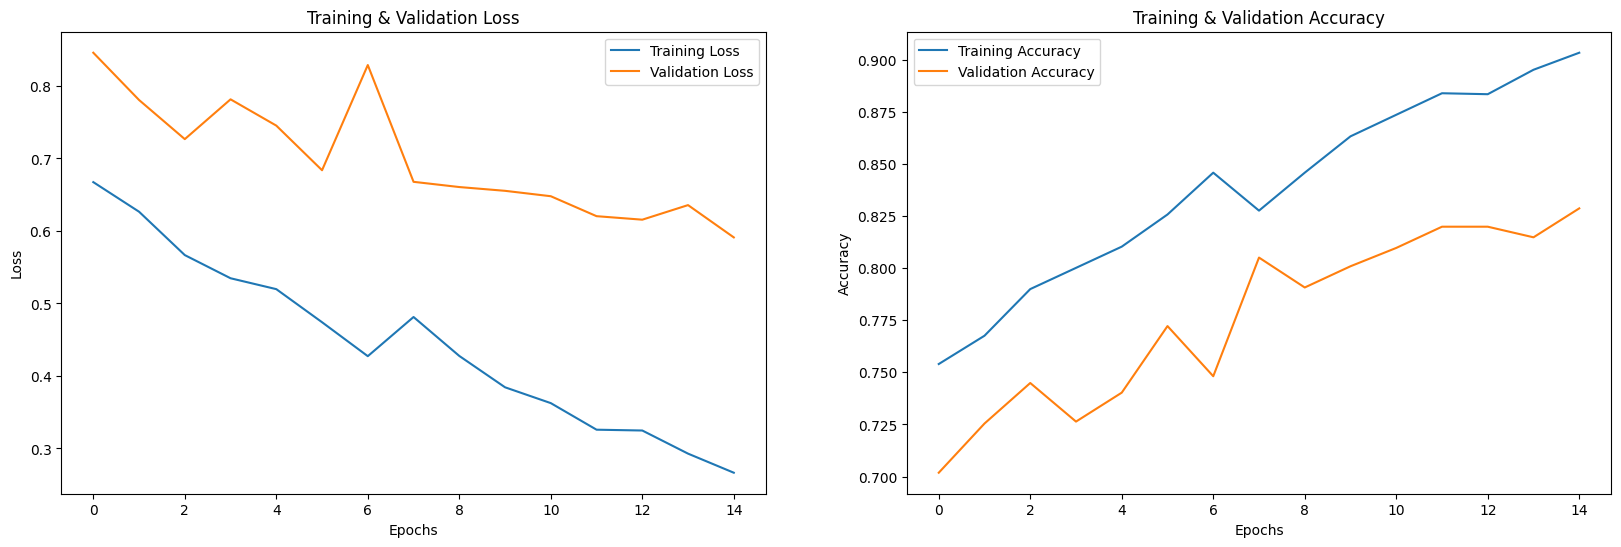

In [ ]:

epochs_range = range(epochs)

plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred_indices = np.array(all_predictions)
y_true_indices = np.array(all_labels)

emotion_labels = encoder.categories_[0]

y_pred_emotion = emotion_labels[y_pred_indices]
y_true_emotion = emotion_labels[y_true_indices]

# Print accuracy
accuracy = (y_pred_indices == y_true_indices).sum() / len(y_true_indices)
print(f"Accuracy of our model on test data: {accuracy * 100:.2f}%")

Accuracy of our model on test data: 82.87%


In [52]:

accuracy = (y_pred_indices == y_true_indices).sum() / len(y_true_indices)
print(f"Accuracy of our model on test data: {accuracy*100:.2f}%")

Accuracy of our model on test data: 82.87%


In [53]:
# Display a DataFrame of Predicted vs Actual Labels
df_results = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df_results['Predicted Labels'] = y_pred_emotion
df_results['Actual Labels'] = y_true_emotion
display(df_results.head(10))

,Predicted Labels,Actual Labels
0,fear,fear
1,angry,angry
2,sad,neutral
3,calm,calm
4,happy,happy
5,sad,sad
6,disgust,disgust
7,happy,happy
8,surprise,surprise
9,calm,calm


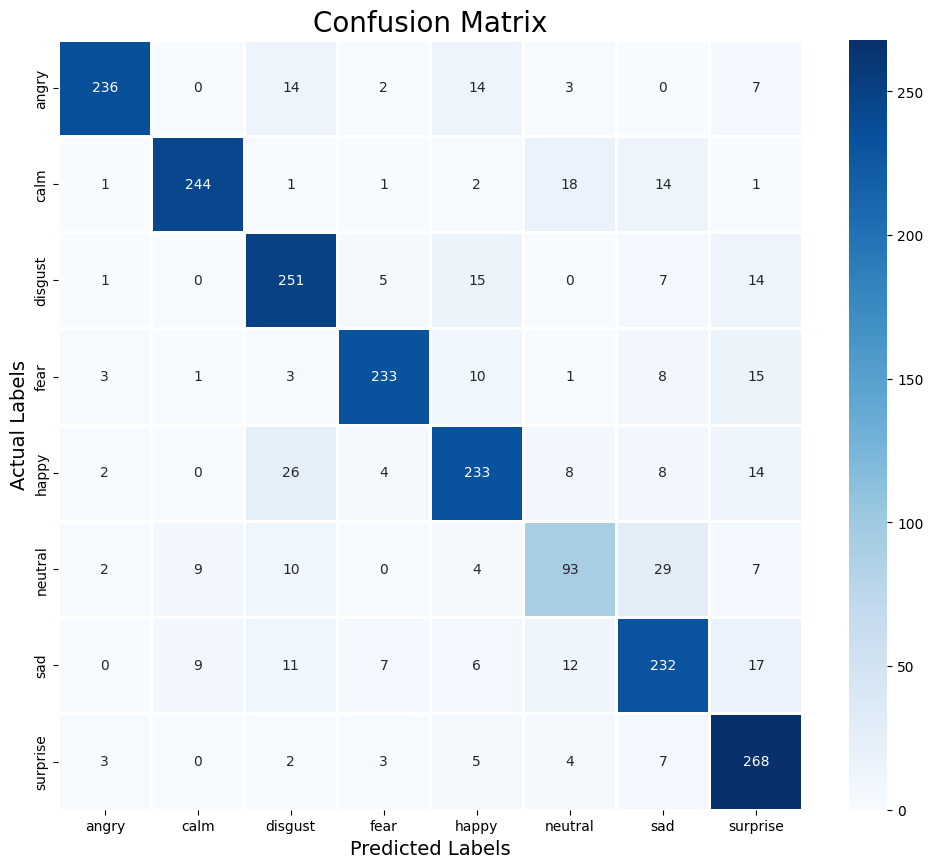

In [54]:
# Confusion Matrix
cm = confusion_matrix(y_true_emotion, y_pred_emotion, labels=emotion_labels)
plt.figure(figsize = (12, 10))
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [55]:
# Classification Report
print(classification_report(y_true_emotion, y_pred_emotion, target_names=emotion_labels))

              precision    recall  f1-score   support

       angry       0.95      0.86      0.90       276
        calm       0.93      0.87      0.90       282
     disgust       0.79      0.86      0.82       293
        fear       0.91      0.85      0.88       274
       happy       0.81      0.79      0.80       295
     neutral       0.67      0.60      0.63       154
         sad       0.76      0.79      0.77       294
    surprise       0.78      0.92      0.84       292

    accuracy                           0.83      2160
   macro avg       0.82      0.82      0.82      2160
weighted avg       0.83      0.83      0.83      2160



In [56]:
path ="/kaggle/working/model.pth"

torch.save(model.state_dict(), path)

print("saved successfully")

saved successfully


In [ ]:
import pkg_resources

packages = [
    "torch",
    "numpy",
    "librosa",
    "scikit-learn", # For the streamlit app
    "pandas",
    "matplotlib",
    "seaborn",
    "streamlit"
]

with open("requirements.txt", "w") as f:
    for package in packages:
        try:
            version = pkg_resources.get_distribution(package).version
            f.write(f"{package}=={version}\n")
        except pkg_resources.DistributionNotFound:
            f.write(f"# {package} not found in environment\n")

print("Generated requirements.txt")

/tmp/ipykernel_1100/1132018031.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Generated requirements.txt
